# Credit Card Fraud Dataset Exploration

In this notebook we will:

1. Explore the transaction dataset
2. Remove unnecessary columns
3. Prepare features for anomaly detection
4. Train a neural network autoencoder to detect anomalous transactions

The goal is to allow the model to learn **normal transaction patterns** and later flag unusual transactions as potential fraud.

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import MinMaxScaler

## Load Dataset

We first load the dataset and inspect the first few rows to understand the structure of the data.

This helps us identify:

- available features
- possible irrelevant columns
- the format of the data

In [2]:
df = pd.read_csv("/content/credit_card_transactions.csv")

df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1.325376e+09,43.150704,-112.154481,0.0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1.325376e+09,47.034331,-112.561071,0.0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1.325376e+09,38.674999,-78.632459,0.0,22844.0


## Inspect Dataset Structure

We check:

- number of rows and columns
- data types
- missing values

This helps us determine which columns require preprocessing.

In [3]:
df.shape

(46334, 24)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46334 entries, 0 to 46333
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             46334 non-null  int64  
 1   trans_date_trans_time  46334 non-null  object 
 2   cc_num                 46334 non-null  int64  
 3   merchant               46334 non-null  object 
 4   category               46334 non-null  object 
 5   amt                    46334 non-null  float64
 6   first                  46334 non-null  object 
 7   last                   46334 non-null  object 
 8   gender                 46334 non-null  object 
 9   street                 46334 non-null  object 
 10  city                   46334 non-null  object 
 11  state                  46334 non-null  object 
 12  zip                    46334 non-null  int64  
 13  lat                    46334 non-null  float64
 14  long                   46334 non-null  float64
 15  ci

In [5]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
count,46334.000000,4.633400e+04,46334.000000,46334.000000,46334.000000,46334.000000,4.633400e+04,4.633300e+04,46333.000000,46333.000000,46333.000000,39275.000000
mean,23166.500000,4.179316e+17,71.649029,48647.348405,38.548603,-90.193063,8.844040e+04,1.326560e+09,38.549454,-90.197568,0.009151,46577.684583
std,13375.618023,1.310230e+18,148.876680,27013.330495,5.087670,13.919090,2.980436e+05,6.806467e+05,5.118002,13.934286,0.095224,25933.050592
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.325376e+09,19.040141,-166.633523,0.000000,1002.000000
25%,11583.250000,1.800429e+14,9.750000,25526.000000,34.690200,-96.798000,7.430000e+02,1.325965e+09,34.794828,-96.901815,0.000000,24553.000000
50%,23166.500000,3.519607e+15,48.290000,48088.000000,39.371600,-87.433500,2.456000e+03,1.326558e+09,39.370033,-87.340721,0.000000,45672.000000
75%,34749.750000,4.642255e+15,83.840000,72011.000000,41.894800,-80.065200,2.047800e+04,1.327152e+09,41.936788,-80.131332,0.000000,67952.000000
max,46333.000000,4.992346e+18,11872.210000,99783.000000,65.689900,-67.950300,2.906700e+06,1.327750e+09,66.659242,-66.967742,1.000000,99403.000000


## Missing Values

Missing data can affect model performance. We check whether any columns contain null values.

In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


## Removing Irrelevant Columns

Some columns contain identifiers or personal information that do not contribute to fraud detection.

Examples include:

- customer names
- transaction IDs
- addresses

These features do not represent transaction behavior and are removed to reduce noise in the dataset.

In [8]:
columns_to_drop = [
    "Unnamed: 0",
    "cc_num",
    "first",
    "last",
    "street",
    "zip",
    "job",
    "dob",
    "trans_num",
    "merch_zipcode"
]

df = df.drop(columns=columns_to_drop)

df.head()

,trans_date_trans_time,merchant,category,amt,gender,city,state,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,36.0788,-81.1781,3495,1.325376e+09,36.011293,-82.048315,0.0
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,48.8878,-118.2105,149,1.325376e+09,49.159047,-118.186462,0.0
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,42.1808,-112.2620,4154,1.325376e+09,43.150704,-112.154481,0.0
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,46.2306,-112.1138,1939,1.325376e+09,47.034331,-112.561071,0.0
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,38.4207,-79.4629,99,1.325376e+09,38.674999,-78.632459,0.0


In [9]:
df.isnull().sum()

,0
trans_date_trans_time,0
merchant,0
category,0
amt,0
gender,0
city,0
state,0
lat,0
long,0
city_pop,0


In [10]:
df = df.dropna()

In [11]:
df.isnull().sum()

,0
trans_date_trans_time,0
merchant,0
category,0
amt,0
gender,0
city,0
state,0
lat,0
long,0
city_pop,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46333 entries, 0 to 46332
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  46333 non-null  object 
 1   merchant               46333 non-null  object 
 2   category               46333 non-null  object 
 3   amt                    46333 non-null  float64
 4   gender                 46333 non-null  object 
 5   city                   46333 non-null  object 
 6   state                  46333 non-null  object 
 7   lat                    46333 non-null  float64
 8   long                   46333 non-null  float64
 9   city_pop               46333 non-null  int64  
 10  unix_time              46333 non-null  float64
 11  merch_lat              46333 non-null  float64
 12  merch_long             46333 non-null  float64
 13  is_fraud               46333 non-null  float64
dtypes: float64(7), int64(1), object(6)
memory usage: 5.3+ MB


## Transaction Amount Distribution

Analyzing transaction amounts helps us understand normal spending behavior.

Fraudulent transactions often have unusual transaction values.

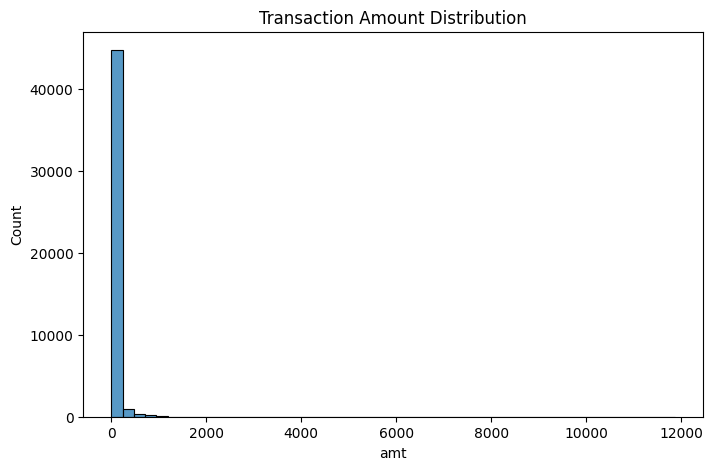

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["amt"], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

## Fraud vs Normal Transactions

We check how many transactions are fraudulent versus normal.

Fraud datasets are usually highly **imbalanced**, meaning fraud cases are very rare compared to legitimate transactions.

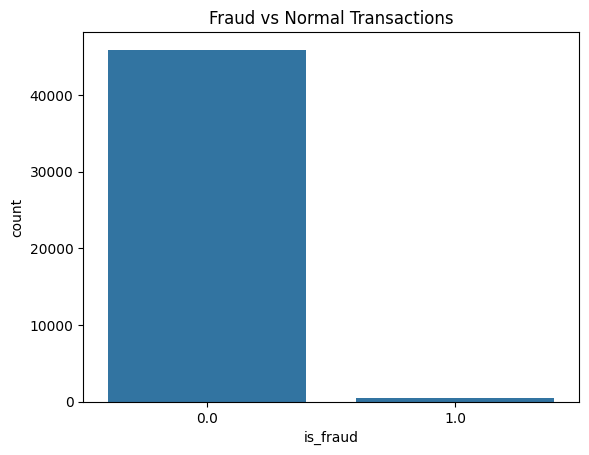

In [14]:
sns.countplot(x="is_fraud", data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

## Extract Time Features

Transaction time can reveal suspicious behavior.

For example:
- transactions late at night
- unusual transaction timing

We extract useful features such as **hour of transaction**.

In [15]:
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])

df["hour"] = df["trans_date_trans_time"].dt.hour
df["day"] = df["trans_date_trans_time"].dt.dayofweek

The original datetime column is dropped because neural networks require numerical input features.

In [16]:
df = df.drop(columns=["trans_date_trans_time"])

## Encoding Categorical Variables

Machine learning models require numeric input.

Categorical variables such as merchant or transaction category are converted into numerical format using **one-hot encoding**.

In [17]:
df = pd.get_dummies(df, drop_first=True)

## Feature Scaling

Feature scaling ensures that all numerical variables have a similar range.

This prevents features with large values (such as transaction amount) from dominating smaller ones.

In [18]:
scaler = MinMaxScaler()

X = df.drop("is_fraud", axis=1)

X_scaled = scaler.fit_transform(X)

## Preparing Data for Anomaly Detection

For anomaly detection using an autoencoder, we train the neural network **only on normal transactions**.

Why?

The autoencoder learns how normal transactions behave.  
If it encounters a fraudulent or unusual transaction, it will struggle to reconstruct it correctly.

This results in a **high reconstruction error**, which we use to detect anomalies.

In [19]:
# Separate normal and fraud transactions

normal_data = df[df["is_fraud"] == 0]
fraud_data = df[df["is_fraud"] == 1]

# Remove labels
X_normal = normal_data.drop("is_fraud", axis=1)
X_fraud = fraud_data.drop("is_fraud", axis=1)

# Scale again for safety
scaler = MinMaxScaler()

X_normal_scaled = scaler.fit_transform(X_normal)
X_fraud_scaled = scaler.transform(X_fraud)

print("Normal transactions:", X_normal_scaled.shape)
print("Fraud transactions:", X_fraud_scaled.shape)

Normal transactions: (45909, 1600)
Fraud transactions: (424, 1600)


## Building the Autoencoder

An **autoencoder** is a neural network that learns to compress and reconstruct data.

It consists of two parts:

Encoder:
Reduces the dimensionality of the input data.

Decoder:
Reconstructs the original data from the compressed representation.

If the transaction is normal, reconstruction error will be small.

If the transaction is anomalous, reconstruction error will be large.

In [33]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

input_dim = X_normal_scaled.shape[1]

# Encoder
input_layer = Input(shape=(input_dim,))
encoder = Dense(32, activation="relu")(input_layer)
encoder = Dense(16, activation="relu")(encoder)
encoder = Dense(8, activation="relu")(encoder)

# Decoder
decoder = Dense(16, activation="relu")(encoder)
decoder = Dense(32, activation="relu")(decoder)
decoder = Dense(input_dim, activation="sigmoid")(decoder)

# Autoencoder model
autoencoder = Model(inputs=input_layer, outputs=decoder)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1600)           │        52,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,384 (411.66 KB)

 Trainable params: 105,384 (411.66 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 879.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 118.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 108.4 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


## Training the Autoencoder

The model is trained only on **normal transactions**.

The goal is for the network to learn how to reconstruct normal transaction patterns.

Fraudulent transactions will later produce **high reconstruction errors**.

In [27]:
history = autoencoder.fit(
    X_normal_scaled,
    X_normal_scaled,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0750 - val_loss: 0.0029
Epoch 2/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 3/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 4/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 5/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 6/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 7/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 8/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0027 - val_loss: 0.0029
Epoch 9/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0027 - val_loss: 0.0028
Epoch 10/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0027 - val_loss: 0.0028
Epoch 11/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 12/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

## Reconstruction Error

After training, we test the model on both normal and fraudulent transactions.

We measure the **difference between the original transaction and the reconstructed one**.

This difference is called the **reconstruction error**.

Large errors indicate anomalies.

In [28]:
# Reconstruction on normal data
reconstructions = autoencoder.predict(X_normal_scaled)

# Compute reconstruction error
mse = np.mean(np.power(X_normal_scaled - reconstructions, 2), axis=1)

error_df = pd.DataFrame({
    "reconstruction_error": mse
})

error_df.head()

1435/1435 ━━━━━━━━━━━━━━━━━━━━ 1s 801us/step


,reconstruction_error
0,0.002675
1,0.002557
2,0.002330
3,0.002630
4,0.002739


## Selecting the Anomaly Threshold

We set a threshold for reconstruction error.

Transactions with error above the threshold are classified as anomalies.

A common approach is to use:

mean + 3 * standard deviation

In [29]:
threshold = error_df["reconstruction_error"].mean() + 3 * error_df["reconstruction_error"].std()

print("Anomaly threshold:", threshold)

Anomaly threshold: 0.0032069892681691366


In [30]:
error_df["reconstruction_error"].isna().sum()

np.int64(0)

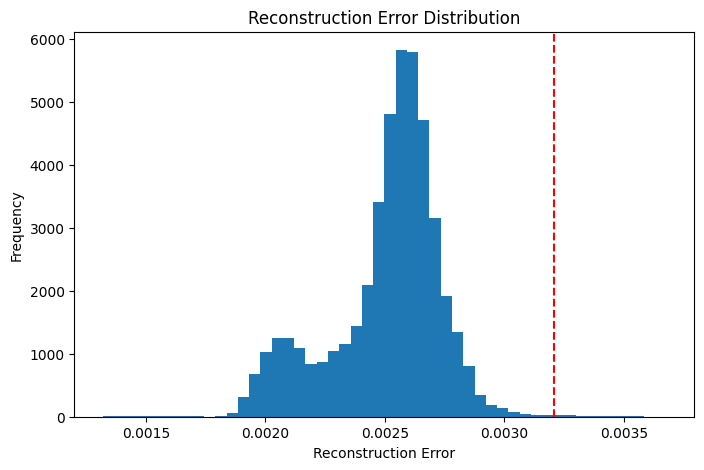

In [31]:
plt.figure(figsize=(8,5))
plt.hist(mse, bins=50)
plt.axvline(threshold, color='red', linestyle='--')
plt.title("Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.show()

In [38]:
X_scaled.shape
np.isnan(X_scaled).sum()

np.int64(0)

In [39]:
normal_data = df[df["is_fraud"] == 0]
fraud_data = df[df["is_fraud"] == 1]

print("Normal:", normal_data.shape)
print("Fraud:", fraud_data.shape)

Normal: (45909, 1603)
Fraud: (424, 1603)


In [40]:
reconstructions = autoencoder.predict(X_normal_scaled)
reconstructions[:5]

1435/1435 ━━━━━━━━━━━━━━━━━━━━ 1s 760us/step


array([[0.49927622, 0.4996101 , 0.49962175, ..., 0.49964938, 0.5001725 ,
        0.49991667],
       [0.49955493, 0.50001407, 0.49960274, ..., 0.49985427, 0.50030625,
        0.5000272 ],
       [0.4997217 , 0.49985343, 0.49973792, ..., 0.50006276, 0.5001786 ,
        0.49985242],
       [0.49994   , 0.50005937, 0.49980533, ..., 0.5000631 , 0.5000159 ,
        0.49971777],
       [0.50001127, 0.49982044, 0.49896806, ..., 0.50039744, 0.50126016,
        0.5006459 ]], dtype=float32)

In [41]:
mse = np.mean(np.power(X_normal_scaled - reconstructions, 2), axis=1)
print("MSE Sample:", mse[:5])
print("MSE stats:", np.min(mse), np.max(mse), np.mean(mse), np.std(mse))

MSE Sample: [0.24947608 0.24931025 0.24928228 0.24929708 0.24950262]
MSE stats: 0.24880440807998055 0.2498287777969413 0.249229031140073 0.00012743074014524654


In [42]:
threshold = mse.mean() + 3*np.std(mse)
print("Threshold:", threshold)

Threshold: 0.24961132336050873


# Step 15-16: Anomaly Detection using Autoencoder

**Goal:** Detect unusual transactions (potential frauds) using the trained autoencoder.

- The autoencoder was trained **only on normal transactions**.
- We use it to reconstruct **all transactions**.
- Compute the reconstruction error for each transaction.
- Any transaction with error > threshold is flagged as an anomaly.

In [45]:
# Step 15-16: Generate Anomaly Scores and Labels

# Drop any columns not used in training
X = df.drop(["is_fraud", "reconstruction_error", "anomaly_label"], axis=1, errors='ignore')

# Scale using the same scaler as before
X_scaled = scaler.transform(X)

# Reconstruct transactions using the trained autoencoder
reconstructed = autoencoder.predict(X_scaled)

# Calculate reconstruction error
df["reconstruction_error"] = np.mean(np.power(X_scaled - reconstructed, 2), axis=1)

# Assign anomaly labels based on threshold
threshold = 0.24961132336050873
df["anomaly_label"] = (df["reconstruction_error"] > threshold).astype(int)

# Check how many anomalies were detected
print(df["anomaly_label"].value_counts())

1448/1448 ━━━━━━━━━━━━━━━━━━━━ 1s 732us/step
anomaly_label
0    46194
1      139
Name: count, dtype: int64


# Step 17: Prepare Dataset for Supervised Learning

**Goal:** Use the anomalies detected by the autoencoder as labels,
and train classical classifiers to predict them.

- `anomaly_label` will be the target (0 = normal, 1 = anomaly)
- All other relevant features are used as input

# Step 17: Save Dataset and Autoencoder Model

**Goal:**

1. Save a dataset containing all features and the `anomaly_label` for supervised learning (Logistic Regression / Naive Bayes).  
2. Save the trained autoencoder model so it can be reused later to detect anomalies in new data.  
3. Save the scaler used for preprocessing, because the autoencoder expects scaled inputs.

In [46]:
# Save the DataFrame with anomaly_label for your team
df.to_csv("labeled_transactions.csv", index=False)

In [47]:
from tensorflow.keras.models import save_model

# Save the trained autoencoder model
autoencoder.save("autoencoder_model.h5")

In [48]:
import joblib

# Save the MinMaxScaler used for training
joblib.dump(scaler, "scaler.save")

['scaler.save']

In [49]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [50]:
file_path = '/content/drive/MyDrive/labeled_transactions.csv'

In [51]:
# Save the dataset with anomaly_label directly to Google Drive
df.to_csv(file_path, index=False)

In [52]:
# See first 5 rows
df.head()

,amt,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,hour,day,...,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,reconstruction_error,anomaly_label
0,4.97,36.0788,-81.1781,3495,1.325376e+09,36.011293,-82.048315,0.0,0,1,...,False,False,False,False,False,False,False,False,0.249476,0
1,107.23,48.8878,-118.2105,149,1.325376e+09,49.159047,-118.186462,0.0,0,1,...,False,False,False,False,True,False,False,False,0.249310,0
2,220.11,42.1808,-112.2620,4154,1.325376e+09,43.150704,-112.154481,0.0,0,1,...,False,False,False,False,False,False,False,False,0.249282,0
3,45.00,46.2306,-112.1138,1939,1.325376e+09,47.034331,-112.561071,0.0,0,1,...,False,False,False,False,False,False,False,False,0.249297,0
4,41.96,38.4207,-79.4629,99,1.325376e+09,38.674999,-78.632459,0.0,0,1,...,False,False,True,False,False,False,False,False,0.249503,0


In [55]:
df.columns

Index(['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'hour', 'day',
       ...
       'state_TX', 'state_UT', 'state_VA', 'state_VT', 'state_WA', 'state_WI',
       'state_WV', 'state_WY', 'reconstruction_error', 'anomaly_label'],
      dtype='object', length=1603)

In [56]:
df.shape

(46333, 1603)